In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# Connessione al database
BASE_DIR = os.path.dirname(os.path.abspath(''))
DB_PATH = os.path.join(BASE_DIR, 'db', 'nuclear.db')
conn = sqlite3.connect(DB_PATH)

# Stile grafici
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Setup completato")
print(f"Database: {DB_PATH}")

Setup completato
Database: C:\Users\giuse\Documents\nuclear-data-analysis\db\nuclear.db


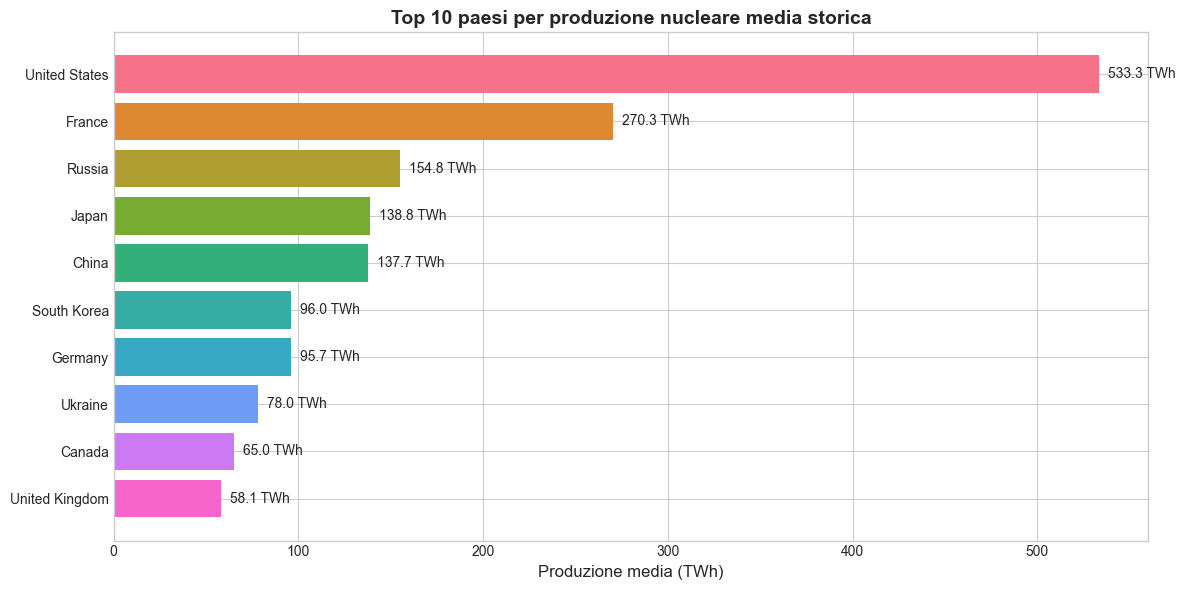

Grafico salvato in plots/


In [2]:
# Leggi i dati dal database con una query SQL
query = """
    SELECT country, ROUND(AVG(nuclear_twh), 1) as media_twh
    FROM nuclear_generation
    WHERE nuclear_twh > 0
    GROUP BY country
    ORDER BY media_twh DESC
    LIMIT 10
"""
df_top10 = pd.read_sql(query, conn)

# Grafico
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_top10['country'], df_top10['media_twh'], 
               color=sns.color_palette('husl', 10))

# Etichette valori sulle barre
for bar, val in zip(bars, df_top10['media_twh']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} TWh', va='center', fontsize=10)

ax.set_xlabel('Produzione media (TWh)', fontsize=12)
ax.set_title('Top 10 paesi per produzione nucleare media storica', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/01_top10_produttori.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

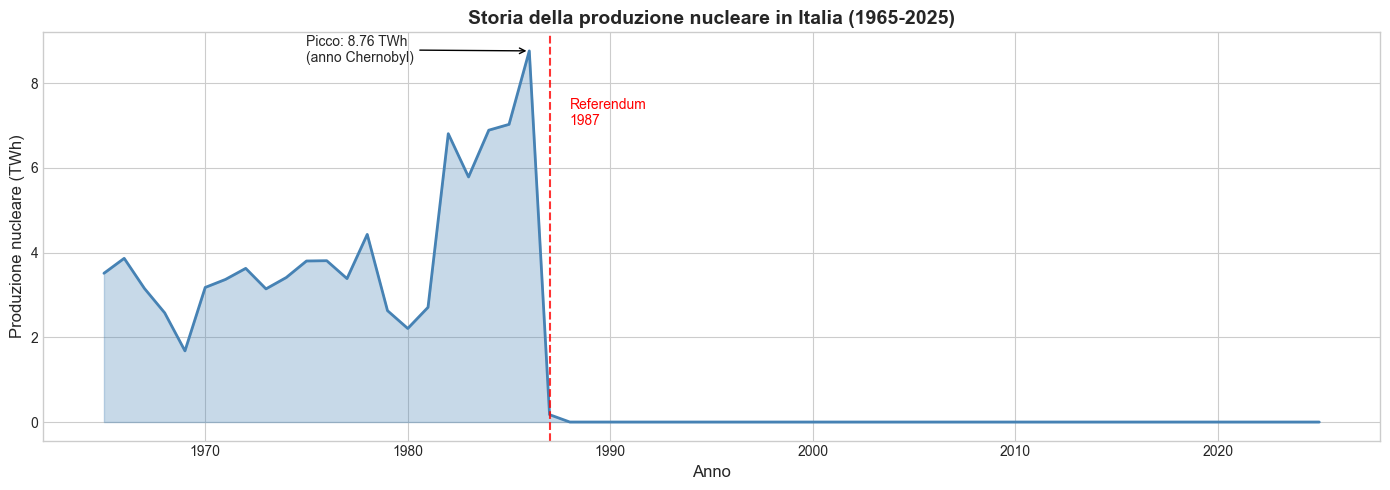

Grafico salvato in plots/


In [3]:
query = """
    SELECT year, nuclear_twh
    FROM nuclear_generation
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_italy['year'], df_italy['nuclear_twh'], 
                alpha=0.3, color='steelblue')
ax.plot(df_italy['year'], df_italy['nuclear_twh'], 
        color='steelblue', linewidth=2)

# Linea verticale referendum
ax.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1988, 7, 'Referendum\n1987', color='red', fontsize=10)

# Punto picco
ax.annotate('Picco: 8.76 TWh\n(anno Chernobyl)',
            xy=(1986, 8.758), xytext=(1975, 8.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Storia della produzione nucleare in Italia (1965-2025)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/02_italia_storia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

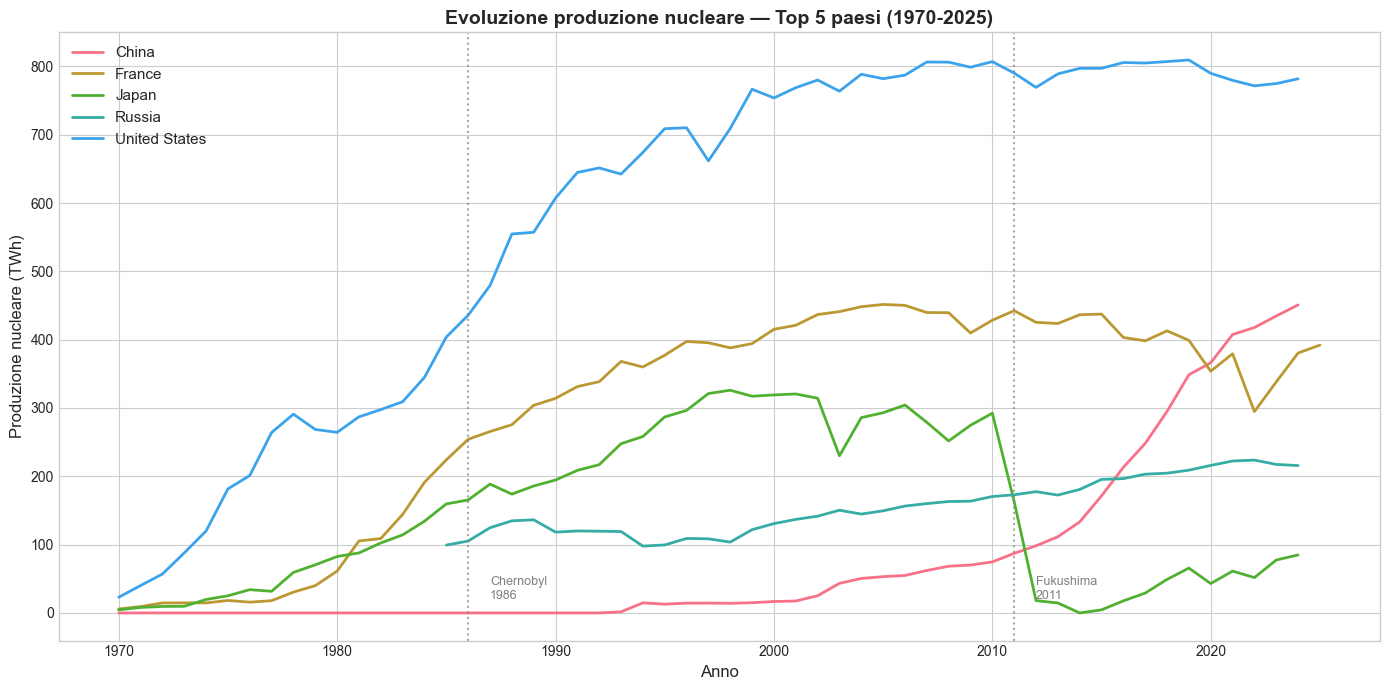

Grafico salvato in plots/


In [4]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('United States', 'France', 'Russia', 'China', 'Japan')
    AND year >= 1970
    ORDER BY country, year
"""
df_trend = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 7))

for country in df_trend['country'].unique():
    df_c = df_trend[df_trend['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], linewidth=2, label=country)

# Linea Chernobyl
ax.axvline(x=1986, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987, 20, 'Chernobyl\n1986', color='gray', fontsize=9)

# Linea Fukushima
ax.axvline(x=2011, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 20, 'Fukushima\n2011', color='gray', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Evoluzione produzione nucleare — Top 5 paesi (1970-2025)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/03_trend_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [5]:
query = """
    SELECT year, nuclear_electricity, nuclear_share_elec, 
           nuclear_share_energy, population
    FROM nuclear_indicators
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy_ind = pd.read_sql(query, conn)

print(f"Anni disponibili: {df_italy_ind['year'].min()} - {df_italy_ind['year'].max()}")
print(f"Righe totali: {len(df_italy_ind)}")
print("\nPrime righe con dati non nulli:")
print(df_italy_ind[df_italy_ind['nuclear_share_elec'].notna()].head(10))

Anni disponibili: 1900 - 2025
Righe totali: 126

Prime righe con dati non nulli:
    year  nuclear_electricity  nuclear_share_elec  nuclear_share_energy  \
85  1985                7.024               3.782                 1.197   
86  1986                8.758               4.554                 1.453   
87  1987                0.174               0.086                 0.028   
88  1988                0.000               0.000                 0.000   
89  1989                0.000               0.000                 0.000   
90  1990                0.000               0.000                 0.000   
91  1991                0.000               0.000                 0.000   
92  1992                0.000               0.000                 0.000   
93  1993                0.000               0.000                 0.000   
94  1994                0.000               0.000                 0.000   

    population  
85  56855499.0  
86  56875982.0  
87  56891919.0  
88  56928748.0  
89  5697

In [6]:
# Rileggiamo il CSV completo perché contiene tutte le fonti energetiche
df_owid = pd.read_csv('../data/raw/owid-energy-data.csv')

# Filtriamo solo l'Italia
cols_italia = ['year', 'nuclear_electricity', 'coal_electricity', 
               'gas_electricity', 'oil_electricity', 'hydro_electricity',
               'solar_electricity', 'wind_electricity', 
               'renewables_electricity', 'electricity_generation']

df_it = df_owid[df_owid['country'] == 'Italy'][cols_italia].copy()
df_it = df_it[df_it['year'] >= 1965].sort_values('year')

print(f"Anni disponibili: {df_it['year'].min()} - {df_it['year'].max()}")
print(f"\nPrime righe:")
print(df_it[df_it['electricity_generation'].notna()].head(10))

Anni disponibili: 1965 - 2025

Prime righe:
       year  nuclear_electricity  coal_electricity  gas_electricity  \
10345  1985                7.024            30.023           24.712   
10346  1986                8.758            31.004           26.871   
10347  1987                0.174            33.035           31.732   
10348  1988                0.000            33.897           32.420   
10349  1989                0.000            31.867           34.407   
10350  1990                0.000            32.050           39.710   
10351  1991                0.000            28.500           36.340   
10352  1992                0.000            21.360           35.480   
10353  1993                0.000            16.660           39.960   
10354  1994                0.000            19.860           40.800   

       oil_electricity  hydro_electricity  solar_electricity  \
10345           76.174             41.092              0.000   
10346           77.483             41.096     

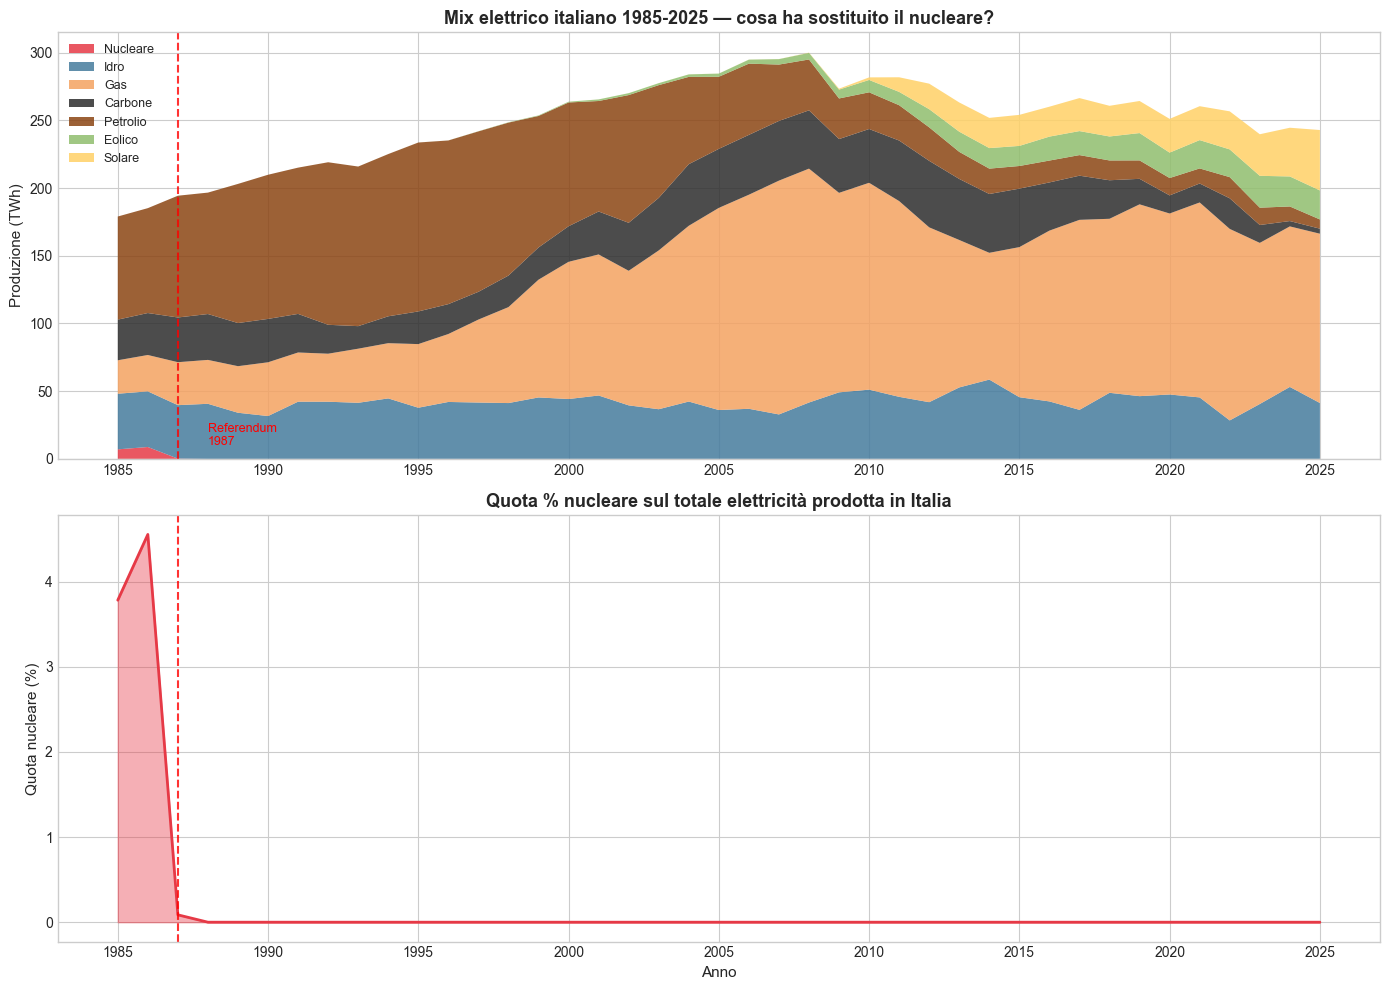

Grafico salvato in plots/


In [7]:
df_plot = df_it[df_it['electricity_generation'].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Grafico superiore: area chart mix energetico ---
ax1 = axes[0]

ax1.stackplot(df_plot['year'],
              df_plot['nuclear_electricity'].fillna(0),
              df_plot['hydro_electricity'].fillna(0),
              df_plot['gas_electricity'].fillna(0),
              df_plot['coal_electricity'].fillna(0),
              df_plot['oil_electricity'].fillna(0),
              df_plot['wind_electricity'].fillna(0),
              df_plot['solar_electricity'].fillna(0),
              labels=['Nucleare', 'Idro', 'Gas', 'Carbone', 'Petrolio', 'Eolico', 'Solare'],
              colors=['#e63946', '#457b9d', '#f4a261', '#2d2d2d', '#8B4513', '#90be6d', '#ffd166'],
              alpha=0.85)

ax1.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(1988, 10, 'Referendum\n1987', color='red', fontsize=9)
ax1.set_ylabel('Produzione (TWh)', fontsize=11)
ax1.set_title('Mix elettrico italiano 1985-2025 — cosa ha sostituito il nucleare?', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# --- Grafico inferiore: quota % nucleare ---
ax2 = axes[1]

# Calcola quota nucleare sul totale
df_plot['quota_nucleare'] = (df_plot['nuclear_electricity'].fillna(0) / 
                              df_plot['electricity_generation'] * 100)

ax2.fill_between(df_plot['year'], df_plot['quota_nucleare'],
                 alpha=0.4, color='#e63946')
ax2.plot(df_plot['year'], df_plot['quota_nucleare'],
         color='#e63946', linewidth=2)
ax2.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('Quota nucleare (%)', fontsize=11)
ax2.set_title('Quota % nucleare sul totale elettricità prodotta in Italia', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/02b_italia_mix_energetico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [8]:
query = """
    SELECT 
        CASE WHEN year <= 1987 THEN 'Prima (1985-1987)' 
             WHEN year >= 2000 THEN 'Dopo (2000-2010)'
             ELSE NULL END as periodo,
        ROUND(AVG(nuclear_twh), 2) as media_nucleare
    FROM nuclear_generation
    WHERE country = 'Italy'
    AND (year <= 1987 OR (year >= 2000 AND year <= 2010))
    GROUP BY periodo
"""
df_confronto = pd.read_sql(query, conn)
print(df_confronto)

# Dal CSV OWID calcoliamo la crescita del gas
gas_prima = df_it[df_it['year'] <= 1987]['gas_electricity'].mean()
gas_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['gas_electricity'].mean()
oil_prima = df_it[df_it['year'] <= 1987]['oil_electricity'].mean()
oil_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['oil_electricity'].mean()

print(f"\nGas — prima: {gas_prima:.1f} TWh → dopo: {gas_dopo:.1f} TWh (+{gas_dopo-gas_prima:.1f} TWh)")
print(f"Petrolio — prima: {oil_prima:.1f} TWh → dopo: {oil_dopo:.1f} TWh (+{oil_dopo-oil_prima:.1f} TWh)")

             periodo  media_nucleare
0   Dopo (2000-2010)            0.00
1  Prima (1985-1987)            3.91

Gas — prima: 27.8 TWh → dopo: 136.8 TWh (+109.1 TWh)
Petrolio — prima: 81.2 TWh → dopo: 59.8 TWh (+-21.4 TWh)
